Load Data

In [ ]:
import numpy as np

data = np.load("plant_disease_features.npz")
X = data["X_features_selected"]
y = data["y_labels"]
print("Features shape:", X.shape)
print("Classes:", len(np.unique(y)))

Features shape: (54305, 100)
Classes: 38


Split & Scale

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (43444, 100)
Test : (10861, 100)


Train SVM, KNN, Random Forest

In [ ]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "SVM"          : SVC(kernel='rbf', random_state=42),
    "KNN"          : KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} - Done")

SVM - Done
KNN - Done
Random Forest - Done


 Accuracy, F1-Score, 5-Fold CV

In [ ]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import cross_val_score
import pandas as pd

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = round(accuracy_score(y_test, y_pred) * 100, 2)
    f1  = round(f1_score(y_test, y_pred, average='weighted') * 100, 2)
    cv  = round(cross_val_score(model, X_train, y_train, cv=5).mean() * 100, 2)
    results.append([name, acc, f1, cv])

df = pd.DataFrame(results, columns=["Model", "Accuracy %", "F1-Score %", "CV Accuracy %"])
print(df.to_string(index=False))

        Model  Accuracy %  F1-Score %  CV Accuracy %
          SVM       79.02       78.63          78.44
          KNN       74.84       74.75          74.65
Random Forest       82.26       81.70          82.08


 Individual vs Combined Features

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd

# X_features and labels must be in memory from feature extraction step

feature_groups = {
    "Color Histogram": X_features[:, 0:768],
    "LBP"            : X_features[:, 768:794],
    "Hu Moments"     : X_features[:, 794:801],
    "Combined"       : X_features
}

comp = []

for fname, fdata in feature_groups.items():
    Xf_train, Xf_test, yf_train, yf_test = train_test_split(
        fdata, labels, test_size=0.2, random_state=42
    )
    sc = StandardScaler()
    Xf_train = sc.fit_transform(Xf_train)
    Xf_test  = sc.transform(Xf_test)

    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(Xf_train, yf_train)
    acc = round(accuracy_score(yf_test, rf.predict(Xf_test)) * 100, 2)
    comp.append([fname, acc])

df_comp = pd.DataFrame(comp, columns=["Feature", "Accuracy %"])
print(df_comp.to_string(index=False))

        Feature  Accuracy %
Color Histogram       92.45
            LBP       51.72
     Hu Moments       27.49
       Combined       93.33


Graph: Model Comparison

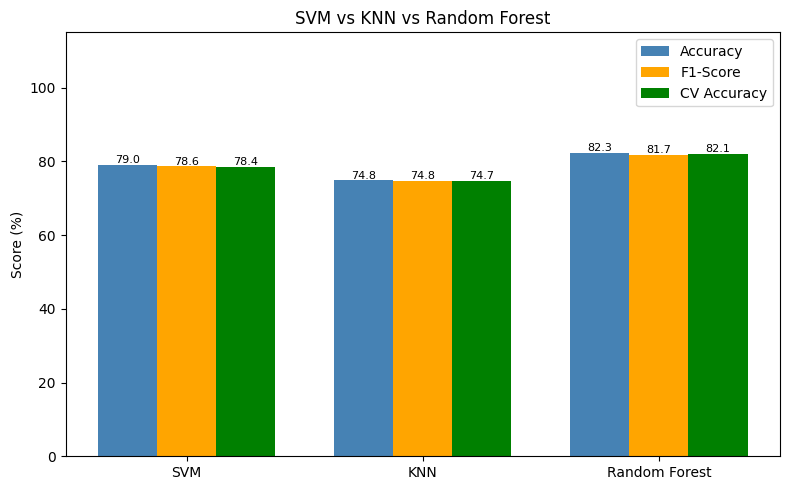

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

names = df["Model"]
x     = np.arange(len(names))
w     = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w, df["Accuracy %"],    w, label="Accuracy",    color="steelblue")
ax.bar(x,     df["F1-Score %"],    w, label="F1-Score",    color="orange")
ax.bar(x + w, df["CV Accuracy %"], w, label="CV Accuracy", color="green")

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f"{bar.get_height():.1f}",
            ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel("Score (%)")
ax.set_title("SVM vs KNN vs Random Forest")
ax.set_ylim(0, 115)
ax.legend()
plt.tight_layout()
plt.show()

Graph: Individual vs Combined Features

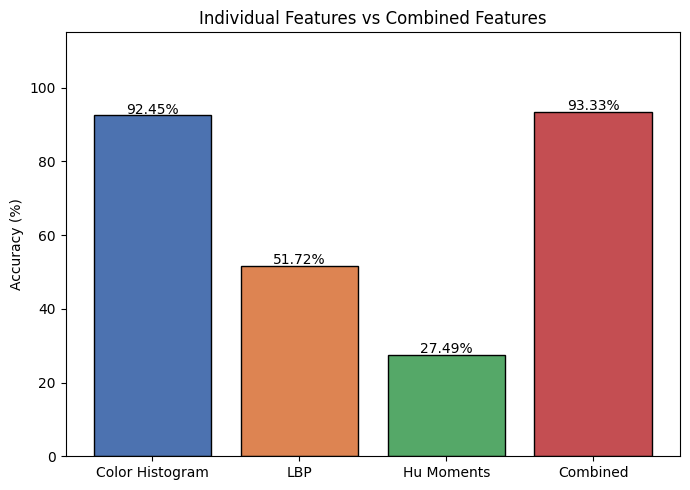

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(df_comp["Feature"], df_comp["Accuracy %"],
              color=['#4C72B0','#DD8452','#55A868','#C44E52'],
              edgecolor='black')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f"{bar.get_height()}%",
            ha='center', fontsize=10)

ax.set_ylabel("Accuracy (%)")
ax.set_title("Individual Features vs Combined Features")
ax.set_ylim(0, 115)
plt.tight_layout()
plt.show()

Confusion Matrix

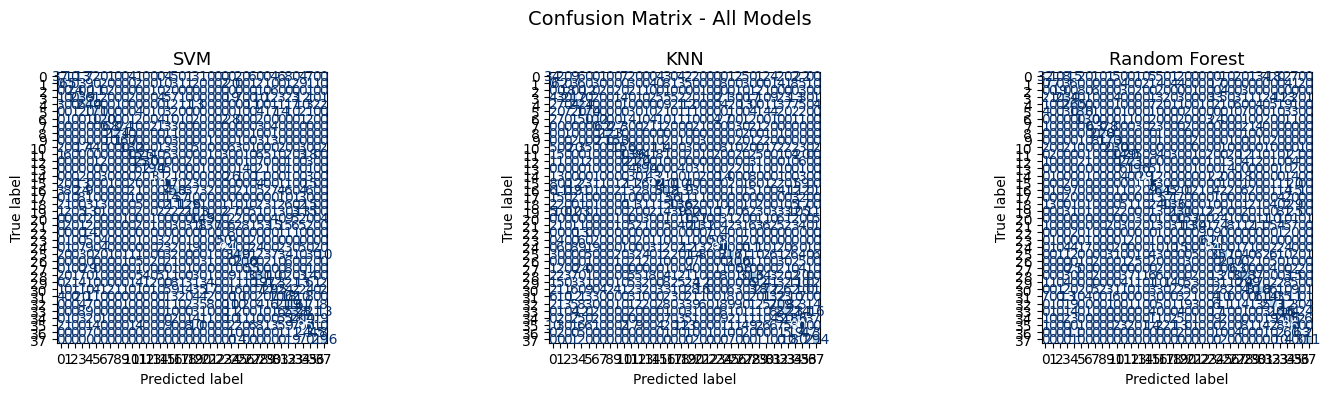

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=13)

plt.suptitle("Confusion Matrix - All Models", fontsize=14)
plt.tight_layout()
plt.show()

Best Model Summary

In [ ]:
pythonbest = df.loc[df["Accuracy %"].idxmax()]

print("================================")
print(f"  BEST MODEL  : {pythonbest['Model']}")
print(f"  Accuracy    : {pythonbest['Accuracy %']} %")
print(f"  F1-Score    : {pythonbest['F1-Score %']} %")
print(f"  CV Accuracy : {pythonbest['CV Accuracy %']} %")
print("================================")

  BEST MODEL  : Random Forest
  Accuracy    : 82.26 %
  F1-Score    : 81.7 %
  CV Accuracy : 82.08 %
